# SAC Implementation for Applied Project 1: Deep RL

This notebook implements **Soft Actor-Critic (SAC)** for the second project paper:

**Soft Actor-Critic: Off-Policy Maximum Entropy Deep Reinforcement Learning with a Stochastic Actor**  
Haarnoja, Zhou, Abbeel, Levine, 2018.

The implementation follows the original SAC formulation from the paper:

- stochastic squashed Gaussian actor,
- two soft Q-functions,
- separate soft value function,
- target value network with Polyak averaging,
- replay buffer and off-policy updates,
- entropy-regularized actor objective.

In [23]:
# If needed:
# !pip install gymnasium[classical-control] pandas

import os
import json
import time
import pickle
import random
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal

try:
    import gymnasium as gym
    GYMNASIUM = True
except ImportError:
    import gym
    GYMNASIUM = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Using gymnasium:", GYMNASIUM)


Using device: cuda
Using gymnasium: True


# SAC idea

SAC optimizes a maximum-entropy objective. Instead of only maximizing expected return, the policy also maximizes entropy:

```text
sum_t E[r(s_t, a_t) + alpha H(pi(. | s_t))]
```

The entropy term encourages exploration and makes the learned policy less brittle. The paper also emphasizes that SAC is off-policy, so it can reuse past transitions from a replay buffer, unlike PPO.

The original SAC paper uses three learned components:

1. A soft Q-function `Q(s, a)`.
2. A soft value function `V(s)`.
3. A stochastic policy `pi(a | s)`.

This implementation uses two Q-functions and takes their minimum to reduce positive Q-value bias.


# Setup and configuration


In [24]:
@dataclass
class SACConfig:
    env_name: str = "Pendulum-v1"

    # Training
    total_steps: int = 100_000
    start_steps: int = 5_000
    update_after: int = 1_000
    update_every: int = 1
    gradient_steps: int = 1

    # Replay / optimization
    replay_size: int = 200_000
    batch_size: int = 256
    gamma: float = 0.99
    tau: float = 0.005
    lr: float = 3e-4

    # Original SAC uses a fixed entropy temperature and discusses reward scale.
    alpha: float = 0.2
    reward_scale: float = 1.0

    # Networks
    hidden_dim: int = 256
    log_std_min: float = -20.0
    log_std_max: float = 2.0

    # Evaluation
    eval_interval: int = 5_000
    eval_episodes: int = 10
    max_episode_steps: Optional[int] = None


In [25]:
ENVIRONMENTS = {
    "cartpole": "CartPole-v1",
    "mountaincar": "MountainCar-v0",
    "mountaincar_continuous": "MountainCarContinuous-v0",
    "acrobot": "Acrobot-v1",
    "pendulum": "Pendulum-v1",
}

ALGORITHM_NAME = "SAC"
RESULTS_DIR = Path("results") / ALGORITHM_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def reset_env(env, seed=None):
    reset_out = env.reset(seed=seed) if seed is not None else env.reset()
    if isinstance(reset_out, tuple):
        obs, info = reset_out
    else:
        obs = reset_out
    return np.asarray(obs, dtype=np.float32)

def step_env(env, action):
    step_out = env.step(action)
    if len(step_out) == 5:
        obs, reward, terminated, truncated, info = step_out
        info = dict(info)
    else:
        obs, reward, done, info = step_out
        info = dict(info)
        truncated = bool(info.get("TimeLimit.truncated", False))
        terminated = bool(done and not truncated)

    done = bool(terminated or truncated)
    info["terminated"] = bool(terminated)
    info["truncated"] = bool(truncated)
    return np.asarray(obs, dtype=np.float32), float(reward), done, info

def make_env(env_name: str, seed: int):
    env = gym.make(env_name)
    reset_env(env, seed=seed)

    try:
        env.action_space.seed(seed)
        env.observation_space.seed(seed)
    except Exception:
        pass

    if not isinstance(env.action_space, gym.spaces.Box):
        raise ValueError(
            f"SAC here expects a continuous Box action space, but {env_name} has {env.action_space}. "
            "Use Pendulum-v1 or MountainCarContinuous-v0 for the final SAC runs."
        )

    obs_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    action_low = env.action_space.low.astype(np.float32)
    action_high = env.action_space.high.astype(np.float32)
    return env, obs_dim, action_dim, action_low, action_high


# Replay buffer

SAC is off-policy, so transitions are stored and reused for many gradient updates. For time-limit truncations, we store `done=False` so the target can bootstrap from the next state instead of treating a successful timeout as a terminal failure.


In [26]:
class ReplayBuffer:
    def __init__(self, obs_dim: int, action_dim: int, size: int):
        self.obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.next_obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.action_buf = np.zeros((size, action_dim), dtype=np.float32)
        self.reward_buf = np.zeros(size, dtype=np.float32)
        self.done_buf = np.zeros(size, dtype=np.float32)

        self.max_size = size
        self.ptr = 0
        self.size = 0

    def store(self, obs, action, reward, next_obs, done):
        self.obs_buf[self.ptr] = obs
        self.action_buf[self.ptr] = action
        self.reward_buf[self.ptr] = reward
        self.next_obs_buf[self.ptr] = next_obs
        self.done_buf[self.ptr] = done

        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample_batch(self, batch_size: int):
        idxs = np.random.randint(0, self.size, size=batch_size)
        batch = {
            "obs": self.obs_buf[idxs],
            "actions": self.action_buf[idxs],
            "rewards": self.reward_buf[idxs],
            "next_obs": self.next_obs_buf[idxs],
            "dones": self.done_buf[idxs],
        }
        return {k: torch.as_tensor(v, dtype=torch.float32, device=device) for k, v in batch.items()}


# Networks

The actor outputs a Gaussian distribution, samples with the reparameterization trick, and then applies `tanh` so actions stay inside the environment bounds. The log-probability includes the tanh correction, which is important for the entropy term.


In [27]:
def mlp(sizes, activation=nn.ReLU, output_activation=nn.Identity):
    layers = []
    for j in range(len(sizes) - 1):
        act = activation if j < len(sizes) - 2 else output_activation
        layers += [nn.Linear(sizes[j], sizes[j + 1]), act()]
    return nn.Sequential(*layers)

def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer

class SquashedGaussianActor(nn.Module):
    def __init__(self, obs_dim, action_dim, action_low, action_high, hidden_dim=128, log_std_min=-20.0, log_std_max=2.0):
        super().__init__()
        self.net = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden_dim)),
            nn.ReLU(),
            layer_init(nn.Linear(hidden_dim, hidden_dim)),
            nn.ReLU(),
        )
        self.mean_layer = layer_init(nn.Linear(hidden_dim, action_dim), std=0.01)
        self.log_std_layer = layer_init(nn.Linear(hidden_dim, action_dim), std=0.01)

        action_low = torch.as_tensor(action_low, dtype=torch.float32, device=device)
        action_high = torch.as_tensor(action_high, dtype=torch.float32, device=device)
        self.action_scale = (action_high - action_low) / 2.0
        self.action_bias = (action_high + action_low) / 2.0
        self.log_std_min = log_std_min
        self.log_std_max = log_std_max

    def forward(self, obs, deterministic=False, with_logprob=True):
        features = self.net(obs)
        mean = self.mean_layer(features)
        log_std = self.log_std_layer(features)
        log_std = torch.clamp(log_std, self.log_std_min, self.log_std_max)
        std = torch.exp(log_std)

        dist = Normal(mean, std)
        raw_action = mean if deterministic else dist.rsample()
        squashed_action = torch.tanh(raw_action)
        action = self.action_bias + self.action_scale * squashed_action

        log_prob = None
        if with_logprob:
            log_prob = dist.log_prob(raw_action).sum(dim=-1)
            tanh_correction = 2.0 * (np.log(2.0) - raw_action - F.softplus(-2.0 * raw_action))
            log_prob -= tanh_correction.sum(dim=-1)
            log_prob -= torch.log(self.action_scale).sum()

        return action, log_prob

class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.q = nn.Sequential(
            layer_init(nn.Linear(obs_dim + action_dim, hidden_dim)),
            nn.ReLU(),
            layer_init(nn.Linear(hidden_dim, hidden_dim)),
            nn.ReLU(),
            layer_init(nn.Linear(hidden_dim, 1), std=1.0),
        )

    def forward(self, obs, action):
        x = torch.cat([obs, action], dim=-1)
        return self.q(x).squeeze(-1)

class ValueNetwork(nn.Module):
    def __init__(self, obs_dim, hidden_dim=128):
        super().__init__()
        self.v = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden_dim)),
            nn.ReLU(),
            layer_init(nn.Linear(hidden_dim, hidden_dim)),
            nn.ReLU(),
            layer_init(nn.Linear(hidden_dim, 1), std=1.0),
        )

    def forward(self, obs):
        return self.v(obs).squeeze(-1)


# SAC agent

The update follows the paper structure:

- Q target: `r + gamma V_target(s')`
- value target: `min(Q1, Q2)(s, a_pi) - alpha log pi(a_pi | s)`
- policy loss: `alpha log pi(a_pi | s) - min(Q1, Q2)(s, a_pi)`
- target value network: soft update with coefficient `tau`


In [28]:
class SACAgent:
    def __init__(self, obs_dim, action_dim, action_low, action_high, config: SACConfig):
        self.config = config

        self.actor = SquashedGaussianActor(
            obs_dim=obs_dim,
            action_dim=action_dim,
            action_low=action_low,
            action_high=action_high,
            hidden_dim=config.hidden_dim,
            log_std_min=config.log_std_min,
            log_std_max=config.log_std_max,
        ).to(device)

        self.q1 = QNetwork(obs_dim, action_dim, config.hidden_dim).to(device)
        self.q2 = QNetwork(obs_dim, action_dim, config.hidden_dim).to(device)
        self.value = ValueNetwork(obs_dim, config.hidden_dim).to(device)
        self.target_value = ValueNetwork(obs_dim, config.hidden_dim).to(device)
        self.target_value.load_state_dict(self.value.state_dict())

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=config.lr)
        self.q1_optimizer = optim.Adam(self.q1.parameters(), lr=config.lr)
        self.q2_optimizer = optim.Adam(self.q2.parameters(), lr=config.lr)
        self.value_optimizer = optim.Adam(self.value.parameters(), lr=config.lr)

    @torch.no_grad()
    def act(self, obs, deterministic=False):
        obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        action, _ = self.actor(obs_tensor, deterministic=deterministic, with_logprob=False)
        return action.squeeze(0).cpu().numpy().astype(np.float32)

    def update(self, replay_buffer: ReplayBuffer):
        cfg = self.config
        batch = replay_buffer.sample_batch(cfg.batch_size)
        obs = batch["obs"]
        actions = batch["actions"]
        rewards = batch["rewards"]
        next_obs = batch["next_obs"]
        dones = batch["dones"]

        with torch.no_grad():
            q_target = cfg.reward_scale * rewards + cfg.gamma * (1.0 - dones) * self.target_value(next_obs)

        q1_loss = F.mse_loss(self.q1(obs, actions), q_target)
        q2_loss = F.mse_loss(self.q2(obs, actions), q_target)

        self.q1_optimizer.zero_grad()
        q1_loss.backward()
        self.q1_optimizer.step()

        self.q2_optimizer.zero_grad()
        q2_loss.backward()
        self.q2_optimizer.step()

        new_actions, log_probs = self.actor(obs, deterministic=False, with_logprob=True)
        q_pi = torch.min(self.q1(obs, new_actions), self.q2(obs, new_actions))

        with torch.no_grad():
            value_target = q_pi - cfg.alpha * log_probs

        value_loss = F.mse_loss(self.value(obs), value_target)
        self.value_optimizer.zero_grad()
        value_loss.backward()
        self.value_optimizer.step()

        new_actions, log_probs = self.actor(obs, deterministic=False, with_logprob=True)
        q_pi = torch.min(self.q1(obs, new_actions), self.q2(obs, new_actions))
        policy_loss = (cfg.alpha * log_probs - q_pi).mean()

        self.actor_optimizer.zero_grad()
        policy_loss.backward()
        self.actor_optimizer.step()

        with torch.no_grad():
            for param, target_param in zip(self.value.parameters(), self.target_value.parameters()):
                target_param.data.mul_(1.0 - cfg.tau)
                target_param.data.add_(cfg.tau * param.data)

        return {
            "q1_loss": float(q1_loss.item()),
            "q2_loss": float(q2_loss.item()),
            "value_loss": float(value_loss.item()),
            "policy_loss": float(policy_loss.item()),
            "entropy": float((-log_probs).mean().item()),
            "q_pi": float(q_pi.mean().item()),
        }


# Evaluation and training loop

Evaluation uses the deterministic mean action. Training uses random actions at the beginning to fill the replay buffer, then samples from the SAC policy.


In [29]:
@torch.no_grad()
def evaluate_policy(env_name: str, agent: SACAgent, config: SACConfig, seed: int = 0):
    env, _, _, _, _ = make_env(env_name, seed + 10_000)
    returns = []
    successes = []
    mean_abs_actions = []

    goal_position = getattr(env.unwrapped, "goal_position", None)
    is_mountaincar_continuous = "MountainCarContinuous" in env_name

    for episode in range(config.eval_episodes):
        state = reset_env(env, seed=seed + 10_000 + episode)
        done = False
        episode_return = 0.0
        episode_steps = 0
        action_magnitudes = []
        reached_goal = False

        while not done:
            if config.max_episode_steps is not None and episode_steps >= config.max_episode_steps:
                break
            action = agent.act(state, deterministic=True)
            action_magnitudes.append(float(np.mean(np.abs(action))))
            next_state, reward, done, info = step_env(env, action)
            episode_return += reward
            state = next_state
            episode_steps += 1

            if goal_position is not None and state[0] >= goal_position:
                reached_goal = True

        returns.append(episode_return)
        mean_abs_actions.append(float(np.mean(action_magnitudes)) if action_magnitudes else 0.0)
        if is_mountaincar_continuous:
            successes.append(float(reached_goal))

    env.close()
    return {
        "mean_return": float(np.mean(returns)),
        "success_rate": float(np.mean(successes)) if successes else np.nan,
        "mean_abs_action": float(np.mean(mean_abs_actions)),
    }

def train_sac(config: SACConfig, seed: int = 0):
    set_seed(seed)

    env, obs_dim, action_dim, action_low, action_high = make_env(config.env_name, seed)
    agent = SACAgent(obs_dim, action_dim, action_low, action_high, config)
    replay_buffer = ReplayBuffer(obs_dim, action_dim, config.replay_size)

    state = reset_env(env, seed=seed)
    episode_return = 0.0
    episode_steps = 0
    episode_returns = []
    eval_returns = []
    update_logs = []
    latest_stats = {}
    start_time = time.time()

    for step in range(1, config.total_steps + 1):
        if step <= config.start_steps:
            action = env.action_space.sample().astype(np.float32)
        else:
            action = agent.act(state, deterministic=False)

        next_state, reward, done, info = step_env(env, action)
        episode_return += reward
        episode_steps += 1

        manual_timeout = config.max_episode_steps is not None and episode_steps >= config.max_episode_steps
        timeout = bool(info.get("truncated", False)) or manual_timeout
        terminal = bool(info.get("terminated", done and not timeout))
        done_for_buffer = float(terminal)
        replay_buffer.store(state, action, reward, next_state, done_for_buffer)

        state = next_state

        if done or timeout:
            episode_returns.append(episode_return)
            state = reset_env(env)
            episode_return = 0.0
            episode_steps = 0

        if step >= config.update_after and replay_buffer.size >= config.batch_size and step % config.update_every == 0:
            stats_list = []
            for _ in range(config.gradient_steps):
                stats_list.append(agent.update(replay_buffer))
            latest_stats = {key: float(np.mean([row[key] for row in stats_list])) for key in stats_list[0]}

        if step % config.eval_interval == 0 or step == 1 or step == config.total_steps:
            eval_stats = evaluate_policy(config.env_name, agent, config, seed)
            eval_return = eval_stats["mean_return"]
            eval_returns.append((step, eval_return))
            row = {
                "step": step,
                "seed": seed,
                "eval_return": eval_return,
                "time_sec": time.time() - start_time,
                **eval_stats,
                **latest_stats,
            }
            update_logs.append(row)

            print(
                f"seed={seed} | steps={step:6d} | "
                f"eval_return={eval_return:9.2f} | "
                f"success={row.get('success_rate', np.nan):5.2f} | "
                f"mean_abs_action={row.get('mean_abs_action', np.nan):5.3f} | "
                f"policy_loss={row.get('policy_loss', np.nan):8.3f} | "
                f"q1_loss={row.get('q1_loss', np.nan):8.3f} | "
                f"entropy={row.get('entropy', np.nan):6.3f}"
            )

    env.close()

    return {
        "agent": agent,
        "eval_returns": eval_returns,
        "episode_returns": episode_returns,
        "update_logs": update_logs,
        "config": config,
        "env_name": config.env_name,
    }


# Multi-seed aggregation and plots


In [30]:
def run_multiple_seeds(config: SACConfig, seeds: List[int]):
    all_results = []
    for seed in seeds:
        print(f"\n===== SAC training on {config.env_name}, seed {seed} =====")
        result = train_sac(config, seed)
        all_results.append(result)
    return all_results

def extract_eval_curves(all_results):
    steps = [step for step, _ in all_results[0]["eval_returns"]]
    eval_matrix = []
    for result in all_results:
        values = [value for _, value in result["eval_returns"]]
        eval_matrix.append(values)
    return steps, np.array(eval_matrix, dtype=np.float32)

def compute_statistics(eval_matrix):
    return np.mean(eval_matrix, axis=0), np.std(eval_matrix, axis=0)

def moving_average(values, window=20):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return values
    kernel = np.ones(window, dtype=np.float32) / window
    return np.convolve(values, kernel, mode="valid")

def plot_eval_curve(steps, mean, std, title, save_path=None):
    steps = np.asarray(steps)
    plt.figure(figsize=(8, 5))
    plt.plot(steps, mean, label="Mean evaluation return")
    plt.fill_between(steps, mean - std, mean + std, alpha=0.2, label="+/- 1 std across seeds")
    plt.xlabel("Environment steps")
    plt.ylabel("Average episode return")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

def plot_individual_seed_curves(steps, eval_matrix, title, save_path=None):
    steps = np.asarray(steps)
    plt.figure(figsize=(8, 5))
    for seed_idx in range(eval_matrix.shape[0]):
        plt.plot(steps, eval_matrix[seed_idx], alpha=0.75, label=f"Seed {seed_idx}")
    plt.xlabel("Environment steps")
    plt.ylabel("Average episode return")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

def plot_training_returns(all_results, window=20, save_path=None):
    plt.figure(figsize=(8, 5))
    for seed_idx, result in enumerate(all_results):
        returns = moving_average(result["episode_returns"], window=window)
        plt.plot(returns, alpha=0.75, label=f"Seed {seed_idx}")
    plt.xlabel(f"Episode index (moving average window={window})")
    plt.ylabel("Training episode return")
    plt.title("SAC training returns")
    plt.legend()
    plt.grid(True)
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

def plot_update_diagnostics(result, save_path=None):
    logs = [row for row in result["update_logs"] if "q1_loss" in row]
    if not logs:
        print("No update diagnostics available yet.")
        return

    steps = [row["step"] for row in logs]
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(steps, [row["q1_loss"] for row in logs], label="Q1 loss")
    plt.plot(steps, [row["q2_loss"] for row in logs], label="Q2 loss")
    plt.plot(steps, [row["value_loss"] for row in logs], label="Value loss")
    plt.xlabel("Environment steps")
    plt.legend()
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(steps, [row["policy_loss"] for row in logs], label="Policy loss")
    plt.plot(steps, [row["entropy"] for row in logs], label="Entropy")
    plt.xlabel("Environment steps")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=4)

def save_eval_curve_csv(steps, eval_matrix, mean, std, path):
    data = {"step": steps, "mean_return": mean, "std_return": std}
    for seed_idx in range(eval_matrix.shape[0]):
        data[f"seed_{seed_idx}_return"] = eval_matrix[seed_idx]
    df = pd.DataFrame(data)
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return df

def remove_agents_from_results(results):
    cleaned = []
    for result in results:
        result_clean = dict(result)
        result_clean.pop("agent", None)
        result_clean["config"] = asdict(result_clean["config"])
        cleaned.append(result_clean)
    return cleaned

def save_trained_agent(agent, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "actor": agent.actor.state_dict(),
            "q1": agent.q1.state_dict(),
            "q2": agent.q2.state_dict(),
            "value": agent.value.state_dict(),
            "target_value": agent.target_value.state_dict(),
        },
        path,
    )


# Final SAC Experiment Setup

SAC is only run on continuous-action environments in this notebook. The discrete environments remain DQN/PPO territory unless we implement a separate discrete SAC variant.


In [31]:
seeds = [0, 1, 2]

base_config = SACConfig(
    total_steps=30_000,
    start_steps=2_000,
    update_after=1_000,
    update_every=1,
    gradient_steps=1,
    replay_size=200_000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    lr=3e-4,
    alpha=0.2,
    reward_scale=1.0,
    hidden_dim=256,
    eval_interval=1_000,
    eval_episodes=10,
    max_episode_steps=None,
)

# MountainCarContinuous-v0 is intentionally not in the default final run.
# Its sparse +100 success reward and near-zero inaction reward can make vanilla SAC learn "do nothing".
# Run it only as an explicit failure/sparse-reward diagnostic, and judge it by success_rate, not return alone.
SAC_ENV_KEYS = ["pendulum"]
OPTIONAL_SPARSE_ENV_KEYS = ["mountaincar_continuous"]

print("Seeds:", seeds)
print("Environment keys:", SAC_ENV_KEYS)
print(base_config)


Seeds: [0, 1, 2]
Environment keys: ['pendulum']
SACConfig(env_name='Pendulum-v1', total_steps=30000, start_steps=2000, update_after=1000, update_every=1, gradient_steps=1, replay_size=200000, batch_size=256, gamma=0.99, tau=0.005, lr=0.0003, alpha=0.2, reward_scale=1.0, hidden_dim=256, log_std_min=-20.0, log_std_max=2.0, eval_interval=1000, eval_episodes=10, max_episode_steps=None)


# Hyperparameter Helpers

The report-friendly workflow mirrors the final PPO notebook: compact one-parameter-at-a-time sensitivity experiments, each averaged over 3 seeds. This avoids one-seed grid plots and makes the claims easier to defend.


In [32]:
def make_config(base_config: SACConfig, **kwargs):
    config_copy = SACConfig(**asdict(base_config))
    for key, value in kwargs.items():
        if not hasattr(config_copy, key):
            raise ValueError(f"Unknown SACConfig parameter: {key}")
        setattr(config_copy, key, value)
    return config_copy

def make_variation_configs(base_config: SACConfig, param_name: str, values):
    configs = {}
    for value in values:
        cfg = make_config(base_config, **{param_name: value})
        configs[f"{param_name}={value}"] = cfg
    return configs

def run_hyperparameter_comparison(experiment_name: str, configs: Dict[str, SACConfig], seeds: List[int]):
    comparison_results = {}
    for label, cfg in configs.items():
        print(f"\n========== {experiment_name}: {label} ==========")
        all_results = run_multiple_seeds(cfg, seeds)
        steps, eval_matrix = extract_eval_curves(all_results)
        mean, std = compute_statistics(eval_matrix)
        comparison_results[label] = {
            "steps": steps,
            "eval_matrix": eval_matrix,
            "mean": mean,
            "std": std,
            "config": cfg,
            "all_results": all_results,
        }
    return comparison_results

def summarize_results(comparison_results):
    summary = []
    for label, result in comparison_results.items():
        mean = result["mean"]
        std = result["std"]
        steps = result["steps"]
        best_idx = int(np.argmax(mean))
        summary.append({
            "config": label,
            "final_mean": float(mean[-1]),
            "final_std": float(std[-1]),
            "best_mean_during_training": float(mean[best_idx]),
            "best_step": int(steps[best_idx]),
        })
    return sorted(summary, key=lambda row: row["final_mean"], reverse=True)

def plot_hyperparameter_comparison(comparison_results, title, save_path=None):
    plt.figure(figsize=(9, 5))
    for label, result in comparison_results.items():
        steps = np.asarray(result["steps"])
        mean = result["mean"]
        std = result["std"]
        plt.plot(steps, mean, label=label)
        plt.fill_between(steps, mean - std, mean + std, alpha=0.12)
    plt.xlabel("Environment steps")
    plt.ylabel("Average episode return")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# Final Multi-Environment Run

This cell trains SAC on the default continuous-action environment and saves CSV/PNG/model files under `results/SAC/<env-name>/`.

`MountainCarContinuous-v0` is excluded from the default final run because the unshaped environment can reward an inaction local optimum: returns around `0` may mean the agent never reached the goal. If you run it anyway, use the printed `success_rate` and `mean_abs_action` diagnostics.



####################################################################################################
Running SAC final experiment on Pendulum-v1
####################################################################################################

===== SAC training on Pendulum-v1, seed 0 =====
seed=0 | steps=     1 | eval_return= -1070.62 | success=  nan | mean_abs_action=0.003 | policy_loss=     nan | q1_loss=     nan | entropy=   nan
seed=0 | steps=  1000 | eval_return= -1089.73 | success=  nan | mean_abs_action=0.022 | policy_loss=   0.012 | q1_loss=  43.863 | entropy= 1.371
seed=0 | steps=  2000 | eval_return= -1709.65 | success=  nan | mean_abs_action=0.617 | policy_loss=  27.166 | q1_loss=   0.111 | entropy= 0.500
seed=0 | steps=  3000 | eval_return=  -716.24 | success=  nan | mean_abs_action=1.332 | policy_loss=  54.605 | q1_loss=   0.381 | entropy=-0.029
seed=0 | steps=  4000 | eval_return=  -303.24 | success=  nan | mean_abs_action=0.587 | policy_loss=  63.962 | q1_loss=   0.

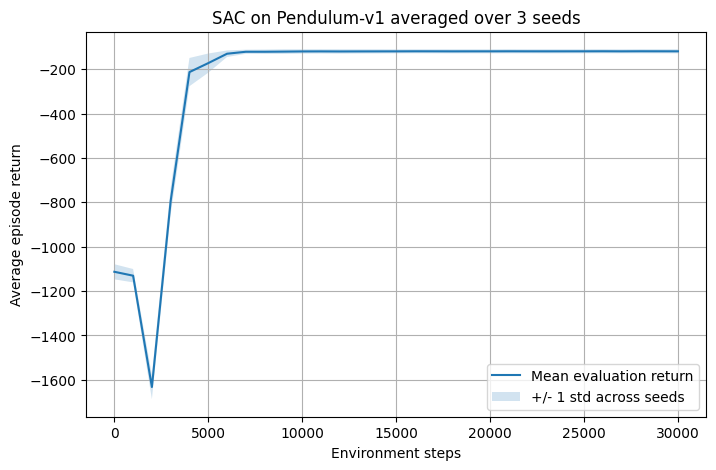

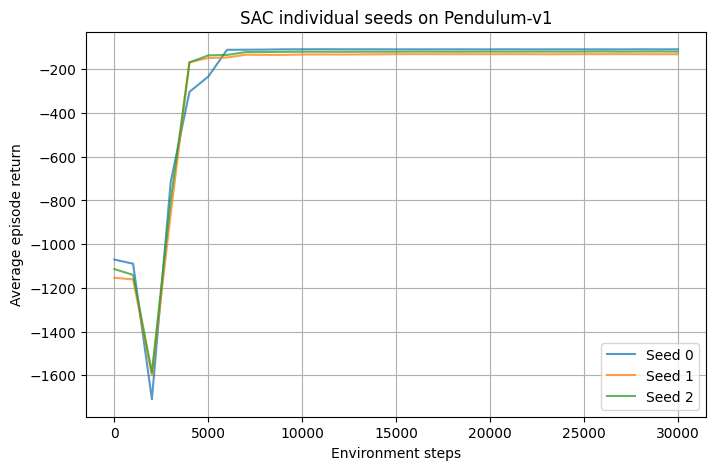

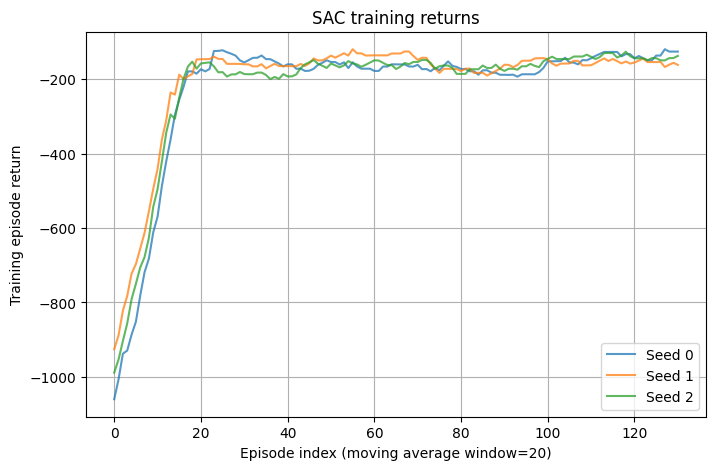

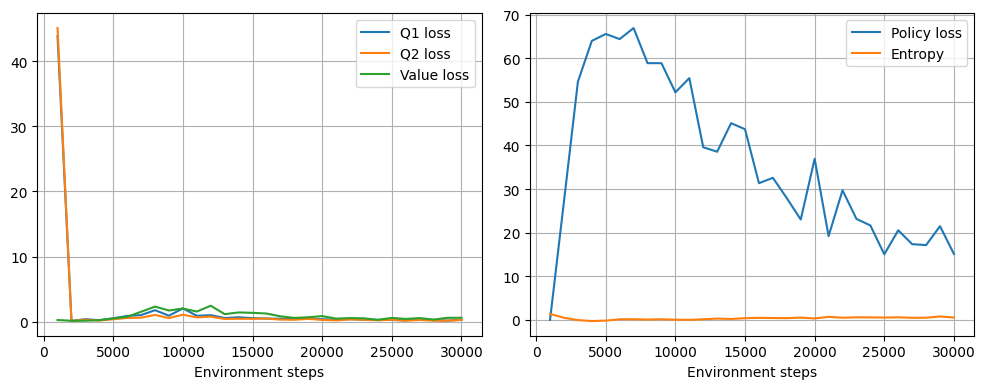

Final mean return: -119.70 +/- 9.23


In [33]:
all_env_results = {}

for ENV_KEY in SAC_ENV_KEYS:
    ENV_NAME = ENVIRONMENTS[ENV_KEY]
    config = make_config(base_config, env_name=ENV_NAME)

    print("\n" + "#" * 100)
    print(f"Running SAC final experiment on {ENV_NAME}")
    print("#" * 100)

    env_result_dir = RESULTS_DIR / ENV_NAME
    env_result_dir.mkdir(parents=True, exist_ok=True)

    final_results = run_multiple_seeds(config, seeds)
    steps, eval_matrix = extract_eval_curves(final_results)
    mean, std = compute_statistics(eval_matrix)

    save_pickle(remove_agents_from_results(final_results), env_result_dir / "final_results_raw.pkl")
    save_json(asdict(config), env_result_dir / "final_config.json")
    save_eval_curve_csv(steps, eval_matrix, mean, std, env_result_dir / "final_eval_curve.csv")

    for seed, result in zip(seeds, final_results):
        save_trained_agent(result["agent"], env_result_dir / f"sac_agent_seed_{seed}.pt")

    plot_eval_curve(
        steps,
        mean,
        std,
        title=f"SAC on {ENV_NAME} averaged over {len(seeds)} seeds",
        save_path=env_result_dir / "final_eval_curve.png",
    )
    plot_individual_seed_curves(
        steps,
        eval_matrix,
        title=f"SAC individual seeds on {ENV_NAME}",
        save_path=env_result_dir / "individual_seed_curves.png",
    )
    plot_training_returns(final_results, window=20, save_path=env_result_dir / "training_returns.png")
    plot_update_diagnostics(final_results[0], save_path=env_result_dir / "update_diagnostics_seed_0.png")

    all_env_results[ENV_NAME] = {
        "config": config,
        "results": final_results,
        "steps": steps,
        "eval_matrix": eval_matrix,
        "mean": mean,
        "std": std,
        "final_mean": float(mean[-1]),
        "final_std": float(std[-1]),
        "best_mean": float(np.max(mean)),
        "best_step": int(steps[int(np.argmax(mean))]),
    }

    print(
        f"Final mean return: {all_env_results[ENV_NAME]['final_mean']:.2f} +/- "
        f"{all_env_results[ENV_NAME]['final_std']:.2f}"
    )


# SAC Hyperparameter Sensitivity

Set `RUN_SENSITIVITY = True` for report plots. By default this runs on Pendulum, where SAC tends to learn quickly enough for practical sensitivity curves.




===== SAC Learning rate sensitivity on Pendulum-v1 =====

========== Learning rate: lr=0.0001 ==========

===== SAC training on Pendulum-v1, seed 0 =====
seed=0 | steps=     1 | eval_return= -1070.62 | success=  nan | mean_abs_action=0.003 | policy_loss=     nan | q1_loss=     nan | entropy=   nan
seed=0 | steps=  1000 | eval_return= -1083.33 | success=  nan | mean_abs_action=0.009 | policy_loss=  -0.052 | q1_loss=  43.863 | entropy= 1.371
seed=0 | steps=  2000 | eval_return= -1731.94 | success=  nan | mean_abs_action=0.295 | policy_loss=  24.304 | q1_loss=   0.658 | entropy= 0.513
seed=0 | steps=  3000 | eval_return= -1161.09 | success=  nan | mean_abs_action=1.463 | policy_loss=  53.366 | q1_loss=   0.687 | entropy= 0.284
seed=0 | steps=  4000 | eval_return=  -996.97 | success=  nan | mean_abs_action=1.275 | policy_loss=  71.425 | q1_loss=   2.030 | entropy=-0.285
seed=0 | steps=  5000 | eval_return= -1115.64 | success=  nan | mean_abs_action=0.981 | policy_loss=  89.683 | q1_loss=

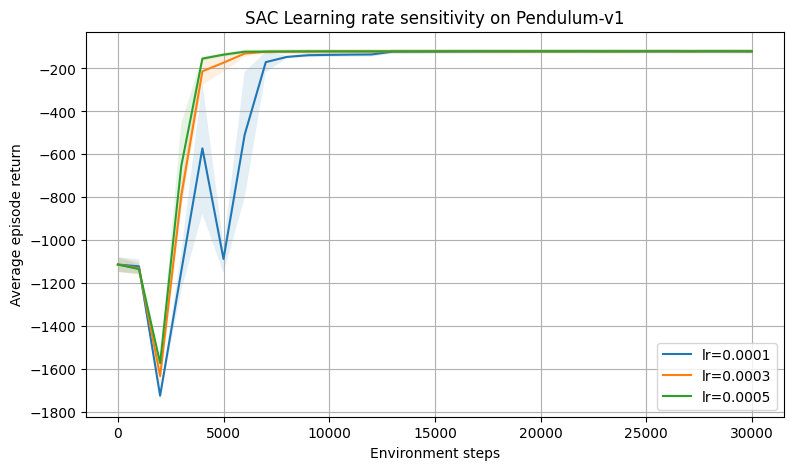



===== SAC Entropy coefficient sensitivity on Pendulum-v1 =====

========== Entropy coefficient: alpha=0.1 ==========

===== SAC training on Pendulum-v1, seed 0 =====
seed=0 | steps=     1 | eval_return= -1070.62 | success=  nan | mean_abs_action=0.003 | policy_loss=     nan | q1_loss=     nan | entropy=   nan
seed=0 | steps=  1000 | eval_return= -1092.14 | success=  nan | mean_abs_action=0.022 | policy_loss=   0.149 | q1_loss=  43.863 | entropy= 1.371
seed=0 | steps=  2000 | eval_return= -1578.14 | success=  nan | mean_abs_action=1.166 | policy_loss=  27.341 | q1_loss=   0.110 | entropy= 0.017
seed=0 | steps=  3000 | eval_return=  -706.01 | success=  nan | mean_abs_action=1.408 | policy_loss=  55.038 | q1_loss=   0.382 | entropy=-0.578
seed=0 | steps=  4000 | eval_return=  -237.96 | success=  nan | mean_abs_action=0.433 | policy_loss=  61.848 | q1_loss=   0.252 | entropy=-0.887
seed=0 | steps=  5000 | eval_return=  -124.56 | success=  nan | mean_abs_action=0.371 | policy_loss=  66.69

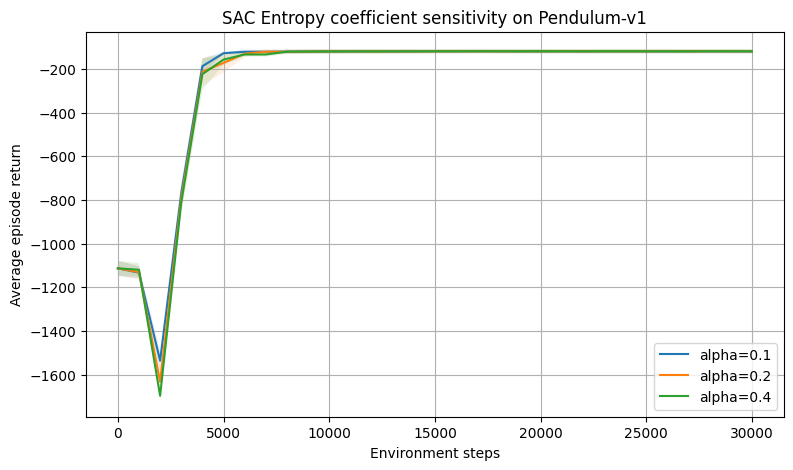



===== SAC Reward scale sensitivity on Pendulum-v1 =====

========== Reward scale: reward_scale=0.5 ==========

===== SAC training on Pendulum-v1, seed 0 =====
seed=0 | steps=     1 | eval_return= -1070.62 | success=  nan | mean_abs_action=0.003 | policy_loss=     nan | q1_loss=     nan | entropy=   nan
seed=0 | steps=  1000 | eval_return= -1089.73 | success=  nan | mean_abs_action=0.022 | policy_loss=   0.012 | q1_loss=   9.242 | entropy= 1.371
seed=0 | steps=  2000 | eval_return= -1692.47 | success=  nan | mean_abs_action=0.525 | policy_loss=  13.637 | q1_loss=   0.013 | entropy= 0.975
seed=0 | steps=  3000 | eval_return=  -686.17 | success=  nan | mean_abs_action=1.180 | policy_loss=  26.718 | q1_loss=   0.047 | entropy= 0.490
seed=0 | steps=  4000 | eval_return=  -140.63 | success=  nan | mean_abs_action=0.375 | policy_loss=  29.848 | q1_loss=   0.036 | entropy= 0.271
seed=0 | steps=  5000 | eval_return=  -123.82 | success=  nan | mean_abs_action=0.331 | policy_loss=  28.655 | q1_

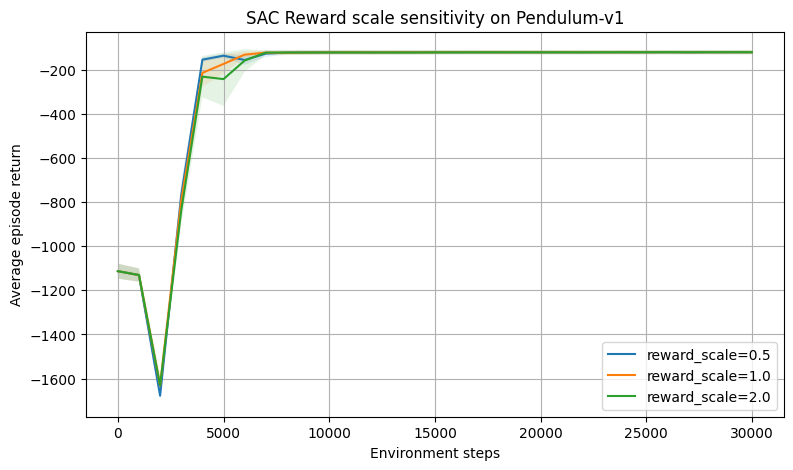



===== SAC Target update tau sensitivity on Pendulum-v1 =====

========== Target update tau: tau=0.005 ==========

===== SAC training on Pendulum-v1, seed 0 =====
seed=0 | steps=     1 | eval_return= -1070.62 | success=  nan | mean_abs_action=0.003 | policy_loss=     nan | q1_loss=     nan | entropy=   nan
seed=0 | steps=  1000 | eval_return= -1089.73 | success=  nan | mean_abs_action=0.022 | policy_loss=   0.012 | q1_loss=  43.863 | entropy= 1.371
seed=0 | steps=  2000 | eval_return= -1709.65 | success=  nan | mean_abs_action=0.617 | policy_loss=  27.166 | q1_loss=   0.111 | entropy= 0.500
seed=0 | steps=  3000 | eval_return=  -716.24 | success=  nan | mean_abs_action=1.332 | policy_loss=  54.605 | q1_loss=   0.381 | entropy=-0.029
seed=0 | steps=  4000 | eval_return=  -303.24 | success=  nan | mean_abs_action=0.587 | policy_loss=  63.962 | q1_loss=   0.228 | entropy=-0.257
seed=0 | steps=  5000 | eval_return=  -233.62 | success=  nan | mean_abs_action=0.408 | policy_loss=  65.545 | 

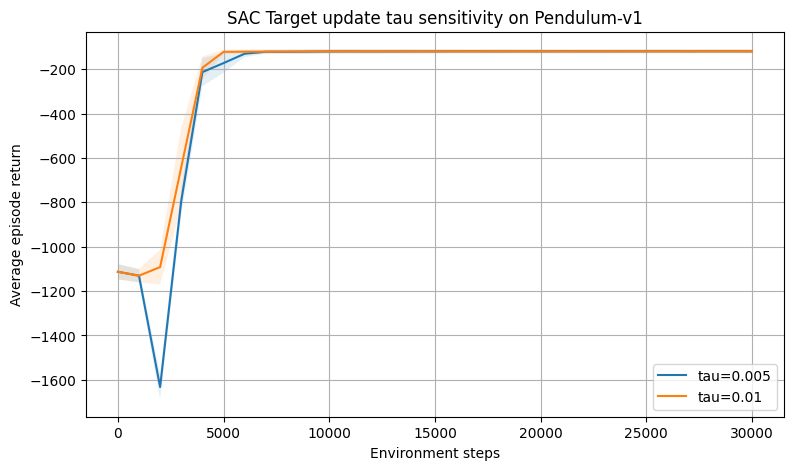

In [34]:
RUN_SENSITIVITY = True
SENSITIVITY_ENV_KEY = "pendulum"
SENSITIVITY_ENV_NAME = ENVIRONMENTS[SENSITIVITY_ENV_KEY]

if RUN_SENSITIVITY:
    env_result_dir = RESULTS_DIR / SENSITIVITY_ENV_NAME
    sensitivity_base = make_config(base_config, env_name=SENSITIVITY_ENV_NAME)
    sensitivity_experiments = {
        "Learning rate": make_variation_configs(sensitivity_base, "lr", [1e-4, 3e-4, 5e-4]),
        "Entropy coefficient": make_variation_configs(sensitivity_base, "alpha", [0.1, 0.2, 0.4]),
        "Reward scale": make_variation_configs(sensitivity_base, "reward_scale", [0.5, 1.0, 2.0]),
        "Target update tau": make_variation_configs(sensitivity_base, "tau", [0.005, 0.01]),
    }

    sensitivity_results = {}
    for experiment_name, configs in sensitivity_experiments.items():
        print(f"\n\n===== SAC {experiment_name} sensitivity on {SENSITIVITY_ENV_NAME} =====")
        results = run_hyperparameter_comparison(experiment_name, configs, seeds)
        sensitivity_results[experiment_name] = results
        safe_experiment_name = experiment_name.lower().replace(" ", "_")

        save_pickle(
            {
                label: {
                    **{k: v for k, v in result.items() if k != "all_results"},
                    "config": asdict(result["config"]),
                    "all_results": remove_agents_from_results(result["all_results"]),
                }
                for label, result in results.items()
            },
            env_result_dir / f"sensitivity_{safe_experiment_name}_raw.pkl",
        )

        summary = summarize_results(results)
        pd.DataFrame(summary).to_csv(env_result_dir / f"sensitivity_{safe_experiment_name}_summary.csv", index=False)

        for row in summary:
            print(
                f"{row['config']:35s} | final = {row['final_mean']:.2f} +/- "
                f"{row['final_std']:.2f} | best = {row['best_mean_during_training']:.2f}"
            )

        plot_hyperparameter_comparison(
            results,
            title=f"SAC {experiment_name} sensitivity on {SENSITIVITY_ENV_NAME}",
            save_path=env_result_dir / f"sensitivity_{safe_experiment_name}_curve.png",
        )
else:
    print("Sensitivity experiments skipped.")


# Compact Result Export

This optional export writes small `.npz` files for cross-algorithm plotting in the report.


In [35]:
SAVE_DIR = Path("sac_saved_results")
SAVE_DIR.mkdir(exist_ok=True)

if "all_env_results" not in globals() or not all_env_results:
    raise NameError("No final SAC environment results found. Run the final multi-environment cell first.")

for env_name, result in all_env_results.items():
    safe_env_name = env_name.replace("-", "_").replace("/", "_")
    save_name = f"sac_final_{safe_env_name}_3seeds"

    np.savez_compressed(
        SAVE_DIR / f"{save_name}.npz",
        steps=np.asarray(result["steps"]),
        eval_matrix=result["eval_matrix"],
        mean=result["mean"],
        std=result["std"],
    )

    metadata = {
        "save_name": save_name,
        "env_name": env_name,
        "config": asdict(result["config"]),
        "num_seeds": len(seeds),
        "final_mean": result["final_mean"],
        "final_std": result["final_std"],
        "best_mean": result["best_mean"],
        "best_step": result["best_step"],
    }

    with open(SAVE_DIR / f"{save_name}_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Saved {env_name} arrays to: {SAVE_DIR / (save_name + '.npz')}")
    print(f"Saved {env_name} metadata to: {SAVE_DIR / (save_name + '_metadata.json')}")


Saved Pendulum-v1 arrays to: sac_saved_results/sac_final_Pendulum_v1_3seeds.npz
Saved Pendulum-v1 metadata to: sac_saved_results/sac_final_Pendulum_v1_3seeds_metadata.json
